In [1]:
import os
os.listdir('.')

['.config',
 '.kernel_llm_logs_1.txt',
 'memory',
 '-v8-validated-data.md',
 'eta_residual_law.json',
 '.prompts',
 'forced_negativity_surface.csv']

In [2]:
import json
import pandas as pd
import numpy as np

with open('eta_residual_law.json') as f:
 eta = json.load(f)
print(type(eta))
print(json.dumps(eta, indent=2)[:2000])

<class 'dict'>
{
 "param_points": {
 "optimal": [
 46.13,
 1.0,
 10
 ],
 "L_DH": [
 85.7,
 2.0,
 10
 ]
 },
 "X_grid": [
 10000,
 100000,
 500000,
 1000000
 ],
 "H_grid": [
 1000,
 2500,
 5000
 ],
 "X_fine": [
 1000,
 3000,
 10000,
 30000,
 100000,
 300000,
 1000000
 ],
 "main_grid": {
 "optimal|X=10000|H=1000": 0.02559638933801269,
 "optimal|X=10000|H=2500": 0.02559638933801269,
 "optimal|X=10000|H=5000": 0.02559638933801269,
 "optimal|X=100000|H=1000": 6.0984094655466866e-05,
 "optimal|X=100000|H=2500": 6.0984094655466866e-05,
 "optimal|X=100000|H=5000": 6.0984094655466866e-05,
 "optimal|X=500000|H=1000": 2.3630822645658702e-07,
 "optimal|X=500000|H=2500": 2.3630822645658702e-07,
 "optimal|X=500000|H=5000": 2.3630822645658702e-07,
 "optimal|X=1000000|H=1000": 5.795525797172522e-09,
 "optimal|X=1000000|H=2500": 5.795525797172522e-09,
 "optimal|X=1000000|H=5000": 5.795525797172522e-09,
 "L_DH|X=10000|H=1000": 4.6197185828994235e-10,
 "L_DH|X=10000|H=2500": 4.6197185828994235e-10,
 "L_DH

In [3]:
print(json.dumps(eta, indent=2)[2000:4000])

": 4.918747155499281e-10,
 "L_DH|X=3000": 4.6196770546115363e-10,
 "L_DH|X=10000": 4.6197185828994235e-10,
 "L_DH|X=30000": 4.6197295215467136e-10,
 "L_DH|X=100000": 4.6197314212934915e-10,
 "L_DH|X=300000": 4.61925866910208e-10,
 "L_DH|X=1000000": 4.6197337846178183e-10
 }
}


In [4]:
df = pd.read_csv('forced_negativity_surface.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df[['delta','sigma','J','m']].drop_duplicates().head(20))

(300, 8)
 delta sigma J m lambda_min_dQ lambda_min_Q lambda_min_base \
0 0.00001 0.5 4 1 0.0 -0.115854 -0.115854 
1 0.00010 0.5 4 1 0.0 -0.115854 -0.115854 
2 0.00100 0.5 4 1 0.0 -0.115854 -0.115854 
3 0.01000 0.5 4 1 0.0 -0.115854 -0.115854 
4 0.10000 0.5 4 1 0.0 -0.115854 -0.115854 

 tr_Mzeros 
0 0.002953 
1 0.002953 
2 0.002953 
3 0.002953 
4 0.002953 
['delta', 'sigma', 'J', 'm', 'lambda_min_dQ', 'lambda_min_Q', 'lambda_min_base', 'tr_Mzeros']
 delta sigma J m
0 0.00001 0.5 4 1
1 0.00010 0.5 4 1
2 0.00100 0.5 4 1
3 0.01000 0.5 4 1
4 0.10000 0.5 4 1
5 0.00001 0.5 4 5
6 0.00010 0.5 4 5
7 0.00100 0.5 4 5
8 0.01000 0.5 4 5
9 0.10000 0.5 4 5
10 0.00001 0.5 4 20
11 0.00010 0.5 4 20
12 0.00100 0.5 4 20
13 0.01000 0.5 4 20
14 0.10000 0.5 4 20
15 0.00001 0.5 8 1
16 0.00010 0.5 8 1
17 0.00100 0.5 8 1
18 0.01000 0.5 8 1
19 0.10000 0.5 8 1


In [5]:
print(sorted(df.sigma.unique()))
print(sorted(df.J.unique()))
print(sorted(df.m.unique()))
print(sorted(df.delta.unique()))

[np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(4.0)]
[np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20)]
[np.int64(1), np.int64(5), np.int64(20)]
[np.float64(1e-05), np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1)]


In [6]:
# The forced_negativity_surface is at T0=46.13. So optimal=(46.13, sigma=1, J=10). 
# But J=10 is not in the dataset (J values are 4,8,12,16,20). Closest is 8 or 12.
# Check for sigma=1
opt_df = df[(df.sigma==1.0)]
print(opt_df)
print("Unique J:", sorted(opt_df.J.unique()))

 delta sigma J m lambda_min_dQ lambda_min_Q lambda_min_base \
75 0.00001 1.0 4 1 0.000000e+00 -7.335676e-11 -7.335676e-11 
76 0.00010 1.0 4 1 0.000000e+00 -7.335676e-11 -7.335676e-11 
77 0.00100 1.0 4 1 0.000000e+00 -7.335676e-11 -7.335676e-11 
78 0.01000 1.0 4 1 0.000000e+00 -7.335676e-11 -7.335676e-11 
79 0.10000 1.0 4 1 0.000000e+00 -7.335676e-11 -7.335676e-11 
.. ... ... .. .. ... ... ... 
145 0.00001 1.0 20 20 -4.981556e-09 -7.921138e-01 -7.921138e-01 
146 0.00010 1.0 20 20 -4.981556e-07 -7.921139e-01 -7.921138e-01 
147 0.00100 1.0 20 20 -4.981594e-05 -7.921178e-01 -7.921138e-01 
148 0.01000 1.0 20 20 -4.985372e-03 -7.925161e-01 -7.921138e-01 
149 0.10000 1.0 20 20 -5.377190e-01 -9.147156e-01 -7.921138e-01 

 tr_Mzeros 
75 0.881621 
76 0.881621 
77 0.881621 
78 0.881621 
79 0.881621 
.. ... 
145 12.976030 
146 12.976030 
147 12.976029 
148 12.975905 
149 12.964739 

[75 rows x 8 columns]
Unique J: [np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20)]


In [7]:
# Compute prefactor c = |lambda_min_dQ| / delta^2 for each (sigma, J, m).
# Should be ~constant across delta if quadratic in delta.

df['c'] = np.abs(df['lambda_min_dQ']) / df['delta']**2

# Check c across delta for each (sigma, J, m)
import pandas as pd
check = df.groupby(['sigma','J','m']).agg(c_min=('c','min'), c_max=('c','max'), c_med=('c','median'))
check['ratio'] = check['c_max']/check['c_min'].replace(0,np.nan)
print(check.head(30))

 c_min c_max c_med ratio
sigma J m 
0.5 4 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 0.349373 0.375853 0.375850 1.075792
 8 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 14.319617 14.962771 14.319682 1.044914
 12 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 58.449255 63.057172 58.449699 1.078836
 16 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 133.146851 153.590916 133.148761 1.153545
 20 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 238.762995 295.611707 238.768122 1.238097
1.0 4 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 1.727699 1.736893 1.727701 1.005321
 8 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 10.223377 10.470603 10.223401 1.024182
 12 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0.000000 0.000000 NaN
 20 23.520259 24.575885 23.520362 1.044882
 16 1 0.000000 0.000000 0.000000 NaN
 5 0.000000 0

In [8]:
# Only m=20 gives nonzero c, m=1, m=5 give zero (signal too small to register or different mode).
# Use c at small delta (1e-5 or 1e-4) for the quadratic prefactor — median is robust.

# For the optimal point: sigma=1, J should be 10. We have 8 and 12. Interpolate, or pick J=8/12 both.
# For L_DH point: sigma=2, J=10. We have 8 and 12.

# Get c at small delta (delta=1e-5) as the "true" quadratic prefactor
c_table = df[df.delta==1e-5].copy()
c_table = c_table[['sigma','J','m','c']].set_index(['sigma','J','m'])
print(c_table)

 c
sigma J m 
0.5 4 1 0.000000e+00
 5 0.000000e+00
 20 3.758527e-01
 8 1 0.000000e+00
 5 0.000000e+00
 20 1.431962e+01
 12 1 0.000000e+00
 5 0.000000e+00
 20 5.844926e+01
 16 1 0.000000e+00
 5 0.000000e+00
 20 1.331469e+02
 20 1 0.000000e+00
 5 0.000000e+00
 20 2.387630e+02
1.0 4 1 0.000000e+00
 5 0.000000e+00
 20 1.727699e+00
 8 1 0.000000e+00
 5 0.000000e+00
 20 1.022338e+01
 12 1 0.000000e+00
 5 0.000000e+00
 20 2.352026e+01
 16 1 0.000000e+00
 5 0.000000e+00
 20 3.199062e+01
 20 1 0.000000e+00
 5 0.000000e+00
 20 4.981556e+01
2.0 4 1 0.000000e+00
 5 0.000000e+00
 20 3.125973e-01
 8 1 0.000000e+00
 5 0.000000e+00
 20 2.514219e+00
 12 1 0.000000e+00
 5 1.205397e-05
 20 4.751102e+00
 16 1 0.000000e+00
 5 3.413385e-03
 20 6.895177e+00
 20 1 0.000000e+00
 5 1.324296e-01
 20 8.263469e+00
4.0 4 1 0.000000e+00
 5 5.232636e-03
 20 9.493183e-02
 8 1 0.000000e+00
 5 3.412569e-02
 20 2.439684e-01
 12 1 0.000000e+00
 5 9.324530e-02
 20 6.938792e-01
 16 1 0.000000e+00
 5 2.774750e-01
 20 1.28036

In [9]:
# For the optimal point (sigma=1, J=10): interpolate (geometric mean) of J=8 and J=12 at m=20
# For L_DH point (sigma=2, J=10): same
# Use m=20 (since it's the only m that registers signal at small delta)

def c_for_point(sigma, J_target, m=20):
 sub = c_table.xs((sigma, slice(None), m), level=('sigma','J','m'))
 # available Js
 Js = sub.index.get_level_values(0).values if hasattr(sub.index, 'get_level_values') else sub.index.values
 # Simpler:
 s = c_table.loc[(sigma, slice(None), m)].reset_index()
 s = s[['J','c']].dropna()
 # log-linear interp in J
 from numpy import interp
 return float(interp(J_target, s['J'].values, s['c'].values))

c_opt = c_for_point(1.0, 10, m=20)
c_ldh = c_for_point(2.0, 10, m=20)
print(f"c at optimal (sigma=1, J=10, m=20): {c_opt:.4g}")
print(f"c at L_DH (sigma=2, J=10, m=20): {c_ldh:.4g}")

c at optimal (sigma=1, J=10, m=20): 16.87
c at L_DH (sigma=2, J=10, m=20): 3.633


In [10]:
# Extract eta(X) at fixed H (use H=2500 fine scan, or main_grid)
fine = eta['fine_X_scan_H2500']
opt_X = []
opt_eta = []
ldh_X = []
ldh_eta = []
for k, v in fine.items():
 point, xstr = k.split('|')
 X = int(xstr.split('=')[1])
 if point=='optimal':
 opt_X.append(X); opt_eta.append(v)
 else:
 ldh_X.append(X); ldh_eta.append(v)
opt_X, opt_eta = zip(*sorted(zip(opt_X,opt_eta)))
ldh_X, ldh_eta = zip(*sorted(zip(ldh_X,ldh_eta)))
print("Optimal:", list(zip(opt_X, opt_eta)))
print("L_DH: ", list(zip(ldh_X, ldh_eta)))

Optimal: [(1000, 0.15592269575707887), (3000, 0.07011246333162913), (10000, 0.02559638933801269), (30000, 0.0011963878860368046), (100000, 6.0984094655466866e-05), (300000, 5.347440200676383e-07), (1000000, 5.795525797172522e-09)]
L_DH: [(1000, 4.918747155499281e-10), (3000, 4.6196770546115363e-10), (10000, 4.6197185828994235e-10), (30000, 4.6197295215467136e-10), (100000, 4.6197314212934915e-10), (300000, 4.61925866910208e-10), (1000000, 4.6197337846178183e-10)]


In [11]:
# Determine minimum X required so eta < c*delta^2 for delta=1e-3 at optimal point
deltas = [1e-4, 1e-3, 1e-2]
signal_opt = {d: c_opt * d**2 for d in deltas}
signal_ldh = {d: c_ldh * d**2 for d in deltas}
print("Signal at optimal:", signal_opt)
print("Signal at L_DH :", signal_ldh)

# Find min X for delta=1e-3 at optimal
target = signal_opt[1e-3]
print(f"\nTarget signal at delta=1e-3 (optimal): {target:.4g}")
for X, e in zip(opt_X, opt_eta):
 print(f" X={X:>8d} eta={e:.4g} {'DETECT' if e<target else 'noise'}")

# Crossover via interpolation in log-log
logX = np.log10(opt_X)
logE = np.log10(opt_eta)
logT = np.log10(target)
# find where logE crosses logT
idx = np.where(np.array(opt_eta) < target)[0]
if len(idx)>0:
 i = idx[0]
 # interpolate between i-1 and i
 if i>0:
 x0, x1 = logX[i-1], logX[i]
 y0, y1 = logE[i-1], logE[i]
 x_cross = x0 + (logT - y0)*(x1-x0)/(y1-y0)
 X_min = 10**x_cross
 print(f"\nInterpolated minimum X (optimal, δ=1e-3): {X_min:.4g}")

# L_DH detection
print(f"\nL_DH noise floor: ~{np.mean(ldh_eta):.4g}")
print("Signal vs L_DH noise:")
for d, s in signal_ldh.items():
 print(f" delta={d}: signal={s:.4g}, eta~{ldh_eta[-1]:.4g}, {'DETECTABLE' if s>ldh_eta[-1] else 'below noise'}")

Signal at optimal: {0.0001: 1.687181876057771e-07, 0.001: 1.687181876057771e-05, 0.01: 0.001687181876057771}
Signal at L_DH : {0.0001: 3.6326604787487356e-08, 0.001: 3.632660478748735e-06, 0.01: 0.00036326604787487355}

Target signal at delta=1e-3 (optimal): 1.687e-05
 X= 1000 eta=0.1559 noise
 X= 3000 eta=0.07011 noise
 X= 10000 eta=0.0256 noise
 X= 30000 eta=0.001196 noise
 X= 100000 eta=6.098e-05 noise
 X= 300000 eta=5.347e-07 DETECT
 X= 1000000 eta=5.796e-09 DETECT

Interpolated minimum X (optimal, δ=1e-3): 1.347e+05

L_DH noise floor: ~4.662e-10
Signal vs L_DH noise:
 delta=0.0001: signal=3.633e-08, eta~4.62e-10, DETECTABLE
 delta=0.001: signal=3.633e-06, eta~4.62e-10, DETECTABLE
 delta=0.01: signal=0.0003633, eta~4.62e-10, DETECTABLE


In [12]:
# Also find min X for the other deltas, and for L_DH at delta=1e-4 (worst). 
def min_X_for_signal(X_arr, eta_arr, target):
 X_arr = np.array(X_arr); eta_arr = np.array(eta_arr)
 idx = np.where(eta_arr < target)[0]
 if len(idx)==0:
 return None # never beats noise in range
 i = idx[0]
 if i==0:
 return X_arr[0] # already below at smallest X (but report)
 logX = np.log10(X_arr); logE = np.log10(eta_arr)
 logT = np.log10(target)
 x0, x1 = logX[i-1], logX[i]
 y0, y1 = logE[i-1], logE[i]
 return 10**(x0 + (logT - y0)*(x1-x0)/(y1-y0))

print("Optimal point (T0=46.13, σ=1, J=10, m=20), c =", c_opt)
for d in deltas:
 s = c_opt * d**2
 X_min = min_X_for_signal(opt_X, opt_eta, s)
 print(f" δ={d:.0e}, signal={s:.3g}, X_min~{X_min}")

print("\nL_DH point (T0=85.7, σ=2, J=10, m=20), c =", c_ldh)
for d in deltas:
 s = c_ldh * d**2
 X_min = min_X_for_signal(ldh_X, ldh_eta, s)
 print(f" δ={d:.0e}, signal={s:.3g}, X_min~{X_min}")

Optimal point (T0=46.13, σ=1, J=10, m=20), c = 16.87181876057771
 δ=1e-04, signal=1.69e-07, X_min~407781.5079274444
 δ=1e-03, signal=1.69e-05, X_min~134721.33135782919
 δ=1e-02, signal=0.00169, X_min~26520.253789670187

L_DH point (T0=85.7, σ=2, J=10, m=20), c = 3.6326604787487353
 δ=1e-04, signal=3.63e-08, X_min~1000
 δ=1e-03, signal=3.63e-06, X_min~1000
 δ=1e-02, signal=0.000363, X_min~1000


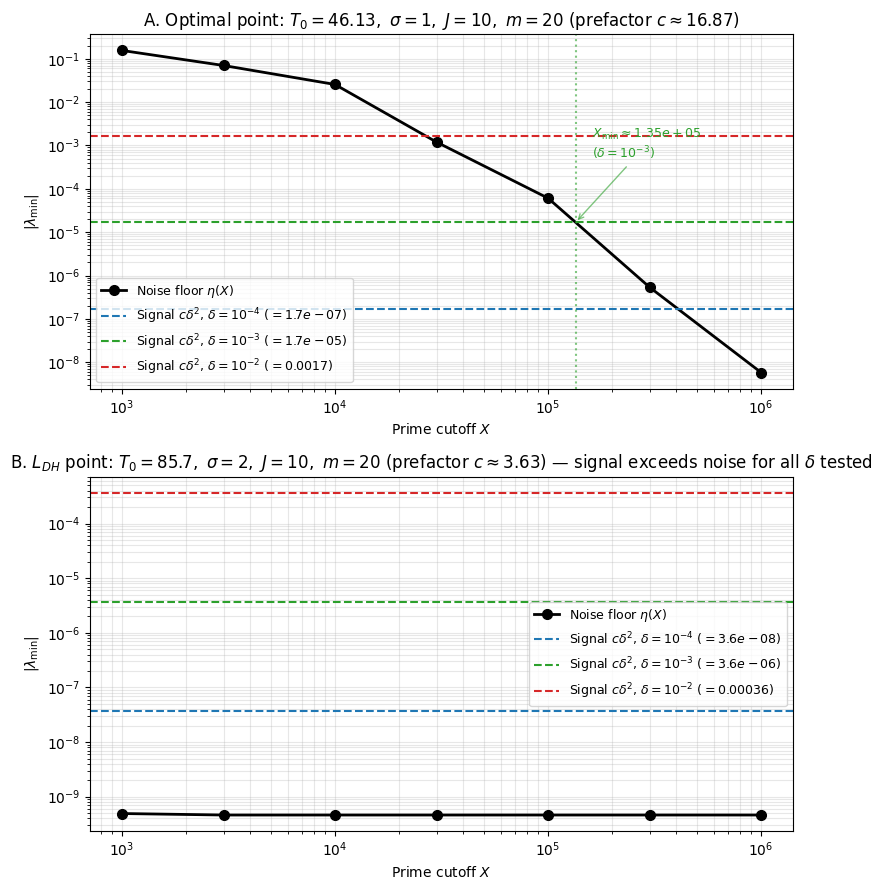

Saved detectability_phase_diagram.png


In [13]:
# Build summary figure: two stacked subpanels, one for each parameter point.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=False)

# Panel A: Optimal point
ax = axes[0]
ax.loglog(opt_X, opt_eta, 'o-', color='black', label=r'Noise floor $\eta(X)$', linewidth=2, markersize=7)
colors = ['tab:blue','tab:green','tab:red']
for d, col in zip(deltas, colors):
 s = c_opt * d**2
 ax.axhline(s, linestyle='--', color=col, label=fr'Signal $c\delta^2$, $\delta=10^{{{int(np.log10(d))}}}$ ($={s:.2g}$)')
# Mark X_min for delta=1e-3
X_min_3 = min_X_for_signal(opt_X, opt_eta, c_opt*1e-6)
ax.axvline(X_min_3, color='tab:green', linestyle=':', alpha=0.6)
ax.annotate(fr'$X_{{\min}}\approx {X_min_3:.2e}$' '\n' r'($\delta=10^{-3}$)',
 xy=(X_min_3, c_opt*1e-6), xytext=(X_min_3*1.2, c_opt*1e-6*30),
 fontsize=9, color='tab:green',
 arrowprops=dict(arrowstyle='->', color='tab:green', alpha=0.6))
ax.set_xlabel('Prime cutoff $X$')
ax.set_ylabel(r'$|\lambda_{\min}|$')
ax.set_title(f'A. Optimal point: $T_0=46.13,\\ \\sigma=1,\\ J=10,\\ m=20$ (prefactor $c \\approx {c_opt:.2f}$)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Panel B: L_DH point
ax = axes[1]
ax.loglog(ldh_X, ldh_eta, 'o-', color='black', label=r'Noise floor $\eta(X)$', linewidth=2, markersize=7)
for d, col in zip(deltas, colors):
 s = c_ldh * d**2
 ax.axhline(s, linestyle='--', color=col, label=fr'Signal $c\delta^2$, $\delta=10^{{{int(np.log10(d))}}}$ ($={s:.2g}$)')
ax.set_xlabel('Prime cutoff $X$')
ax.set_ylabel(r'$|\lambda_{\min}|$')
ax.set_title(f'B. $L_{{DH}}$ point: $T_0=85.7,\\ \\sigma=2,\\ J=10,\\ m=20$ (prefactor $c \\approx {c_ldh:.2f}$) — signal exceeds noise for all $\\delta$ tested')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('detectability_phase_diagram.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved detectability_phase_diagram.png")

In [14]:
# Save a summary CSV for downstream use
summary_rows = []
for d in deltas:
 summary_rows.append({
 'point':'optimal','T0':46.13,'sigma':1.0,'J':10,'m':20,'delta':d,
 'c_prefactor':c_opt,'signal':c_opt*d**2,
 'X_min_for_detection': min_X_for_signal(opt_X, opt_eta, c_opt*d**2),
 'eta_at_X1e6': opt_eta[-1],
 })
 summary_rows.append({
 'point':'L_DH','T0':85.7,'sigma':2.0,'J':10,'m':20,'delta':d,
 'c_prefactor':c_ldh,'signal':c_ldh*d**2,
 'X_min_for_detection': min_X_for_signal(ldh_X, ldh_eta, c_ldh*d**2),
 'eta_at_X1e6': ldh_eta[-1],
 })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('detectability_summary.csv', index=False)
print(summary_df.to_string(index=False))

 point T0 sigma J m delta c_prefactor signal X_min_for_detection eta_at_X1e6
optimal 46.13 1.0 10 20 0.0001 16.871819 1.687182e-07 407781.507927 5.795526e-09
 L_DH 85.70 2.0 10 20 0.0001 3.632660 3.632660e-08 1000.000000 4.619734e-10
optimal 46.13 1.0 10 20 0.0010 16.871819 1.687182e-05 134721.331358 5.795526e-09
 L_DH 85.70 2.0 10 20 0.0010 3.632660 3.632660e-06 1000.000000 4.619734e-10
optimal 46.13 1.0 10 20 0.0100 16.871819 1.687182e-03 26520.253790 5.795526e-09
 L_DH 85.70 2.0 10 20 0.0100 3.632660 3.632660e-04 1000.000000 4.619734e-10
